In [251]:
import scipy as sp
from scipy.special import jv, hankel2, yv, spherical_jn, spherical_yn
import numpy as np
import matplotlib.pyplot as plt
from numpy import sqrt, linspace, zeros, ones
from numpy import pi
from scipy.signal import argrelmin

In [245]:
def hl2(n, x):
    return spherical_jn(n, x) - 1j * spherical_yn(n, x)

def hl2prime(n, x):
    hn = hl2(n, x)
    hn1 = hl2(n+1, x)
    return n/x * hn - hn1

def hl1(n, x):
    return spherical_jn(n, x) + 1j * spherical_yn(n, x)

def hl1prime(n, x):
    hn = hl1(n, x)
    hn1 = hl1(n+1, x)
    return n/x * hn - hn1

In [265]:
epsilon = 2.31
M = 1000
lambdas = linspace(0.4, 5, M)
a = 10
xs = (2*pi/lambdas)*a
ys = xs * sqrt(epsilon) # epsilonkR in the sphere
mode_conditions = zeros((3, M))
for (l_index, l) in enumerate([119, 120, 121]):
    xhl2_prime = hl2(l, xs) + xs * hl2prime(l, xs)
    xhl1_prime = hl1(l, xs) + xs * hl1prime(l, xs)
    yjl_prime = spherical_jn(l, ys) + ys*spherical_jn(l, ys, derivative=True)
    xjl_prime = spherical_jn(l, xs) + xs*spherical_jn(l, xs, derivative=True)

    denominator =  -epsilon * spherical_jn(l, ys) * xhl1_prime + yjl_prime * hl1(l, xs)
    mode_condition = denominator
    mode_conditions[l_index, :] = abs(mode_condition)

In [266]:
mode_idxs = [argrelmin(np.log(mode_condition)) for mode_condition in mode_conditions]

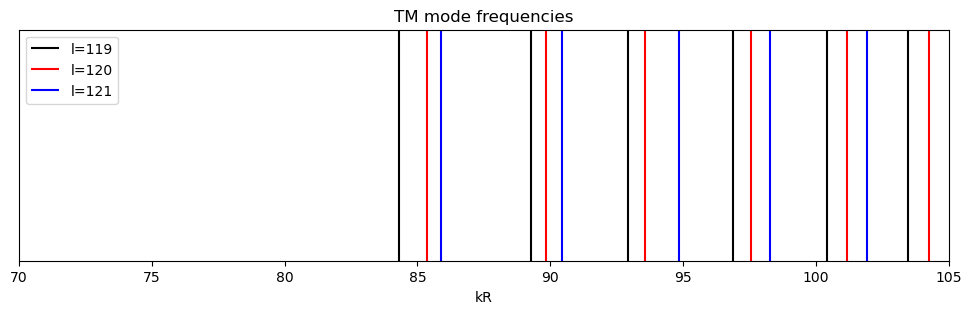

In [289]:
fig, ax = plt.subplots(figsize=(12, 3))
ax.vlines(xs[mode_idxs[0]], 0, 1, color="black", label="l=119")
ax.vlines(xs[mode_idxs[1]], 0, 1, color="red", label="l=120")
ax.vlines(xs[mode_idxs[2]], 0, 1, color="blue", label="l=121")
ax.set_xlim(70, 105)
ax.legend(loc='upper left')
ax.set_ylim(0, 1)
ax.set_title("TM mode frequencies")
ax.set_xlabel("kR")
ax.set_yticks([]);

In [221]:
epsilon = 2.31
l = 120
x1 = 2*pi*a/(85.02+0.003)
x2 = 2*pi*a/(85.02+0.0045)
lambdas = linspace(x2, x1, 2000000)
a = 10
xs = (2*pi/lambdas)*a
ys = xs * sqrt(epsilon) # epsilonkR in the sphere
xhl2_prime = hl2(l, xs) + xs * hl2prime(l, xs)
xhl1_prime = hl1(l, xs) + xs * hl1prime(l, xs)
yjl_prime = spherical_jn(l, ys) + ys*spherical_jn(l, ys, derivative=True)
xjl_prime = spherical_jn(l, xs) + xs*spherical_jn(l, xs, derivative=True)

denominator =  -epsilon * spherical_jn(l, ys) * xhl1_prime + yjl_prime * hl1(l, xs)
mode_condition = denominator

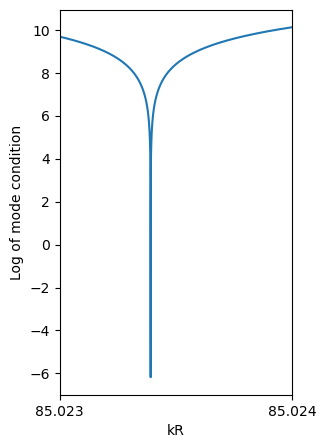

In [244]:
fig, ax = plt.subplots(figsize=(3, 5))
ax.plot(xs, np.log(abs(mode_condition)))
ax.set_xlim(min(xs), max(xs))
ax.set_xticks([min(xs), max(xs)], [round(min(xs), 3), round(max(xs), 3)]);
ax.set_xlabel("kR");
ax.set_ylabel("Log of mode condition");